/home/dark-c/myenv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(



Gene Expression Data
Condition A:  [12 15 14 13 16 15]
Condition B:  [22 25 20 27 24 23]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_A, mu_B]


/home/dark-c/myenv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



--Posterior Means--
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_A             14.223  1.472  11.499   17.029      0.023    0.022    4227.0   
mu_B             23.444  1.946  19.957   27.218      0.033    0.029    3511.0   
log_fold_change   0.502  0.134   0.257    0.757      0.002    0.002    3697.0   

                 ess_tail  r_hat  
mu_A               3186.0    1.0  
mu_B               2976.0    1.0  
log_fold_change    2892.0    1.0  

Probability (mu_B > mu_A):  0.99975


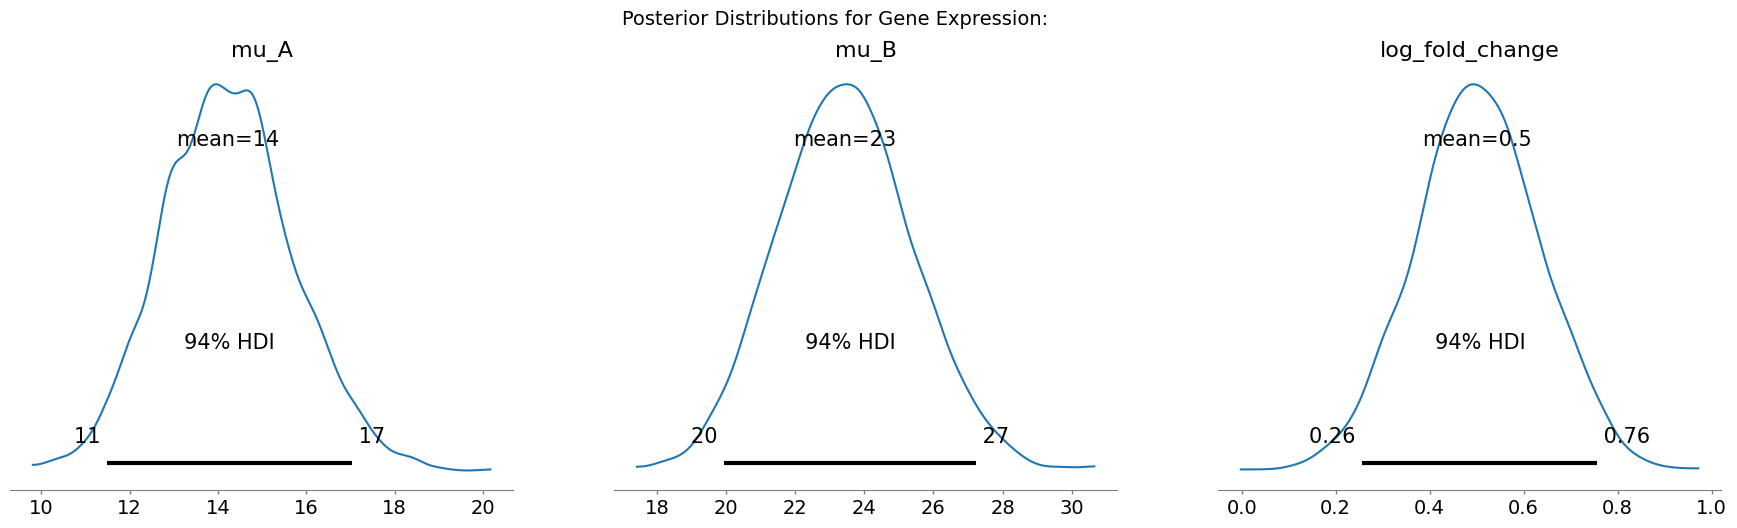

In [1]:
# The program uses Bayesian modeling to determine whether gene expression in Condition B is higher than in Condition A and by how much.
import pymc as pm # Bayesian probabilistic modeling
import arviz as az # Posterior analysis and visualization
import numpy as np # Numerical arrays
import matplotlib.pyplot as plt # Plotting

expr_A = np.array([12, 15, 14, 13, 16, 15]) # Condition A -> lower counts (~13-16)
expr_B = np.array([22, 25, 20, 27, 24, 23]) # Condition B -> higher counts (~20-27)
print("\nGene Expression Data")
print("Condition A: ", expr_A)
print("Condition B: ", expr_B)

with pm.Model() as model: # This defines a probabilistic model
    mu_A = pm.HalfNormal("mu_A", sigma = 20)
    mu_B = pm.HalfNormal("mu_B", sigma = 20)
    # mu_A and mu_B are the true mean expression levels
    # HalfNormal ensures they are positive
    # sigma=20 is a wide prior (weakly informative)
    
    obs_A = pm.Poisson("obs_A", mu = mu_A, observed = expr_A)
    obs_B = pm.Poisson("obs_B", mu = mu_B, observed = expr_B)
    # We assume:
    # Expression counts follow a Poisson distribution
    # The Poisson rate parameter = mu_A or mu_B
    # This is appropriate for count data.

    # Log Fold Change
    log_fc = pm.Deterministic("log_fold_change", pm.math.log(mu_B / mu_A))
    # Sampling from the Posterior
    trace = pm.sample(
        2000, # 2000 tuning steps
        tune = 2000, # 2000  posterior samples
        return_interencedata = True # Returns an ArviZ InferenceData object
    )
print("\n--Posterior Means--")
# Posterior Summary
print(az.summary(trace, var_names = ["mu_A", "mu_B", "log_fold_change"]))
prob_B_greater = (trace.posterior["mu_B"] > trace.posterior["mu_A"]).mean().item()
print("\nProbability (mu_B > mu_A): ", prob_B_greater)

# Visualization
az.plot_posterior(trace, var_names = ["mu_A", "mu_B", "log_fold_change"])
plt.suptitle("Posterior Distributions for Gene Expression: ", fontsize=14)
plt.show()